# All you need to know about Taylor Swift lyrics

Say something here later


## Getting start

In [115]:
from bs4 import BeautifulSoup
import re
import lyricsgenius
import requests
from pathlib import Path
import pandas as pd
import numpy as np

## Import data

In [117]:
ts_lyrics = pd.read_csv("taylor_swift_genius_data.csv")

In [118]:
ts_lyrics["Album"].unique()

array(['Taylor Swift', 'Fearless taylors version',
       'Speak Now taylors version', 'Red taylors version',
       '1989 taylors version', 'Reputation', 'Lover',
       'folklore deluxe version', 'evermore deluxe version',
       'Midnights 3am edition',
       'The tortured poets department the antholog',
       'The life of a showgirl', 'non album'], dtype=object)

## Analysing lyrics by album

In [120]:
### Adding album year
album_years = pd.DataFrame({
    "Album": [
        "Taylor Swift",
        "Fearless taylors version",
        "Speak Now taylors version",
        "Red taylors version",
        "1989 taylors version",
        "Reputation",
        "Lover",
        "folklore deluxe version",
        "evermore deluxe version",
        "Midnights 3am edition",
        "The tortured poets department the antholog",
        "The life of a showgirl"
    ],
    "Year": [2006, 2008, 2010, 2012, 2014, 2017, 2019, 2020, 2021, 2022, 2024, 2025]
})

In [121]:
pivot_words = ts_lyrics.groupby("Album").agg(
    Total_Words=("Lyrics", lambda x: x.str.split().apply(len).sum()),
    Unique_Words=("Lyrics", lambda x: len(set(' '.join(x).split()))),
    Total_Tracks=("Song Name", "count"),
    Words_Per_Track=("Lyrics", lambda x: round(x.str.split().apply(len).mean(), 1)),
    Unique_Words_Per_Track=("Lyrics", lambda x: round(x.apply(lambda s: len(set(s.split()))).mean(), 1))
).reset_index()
pivot_words["Ratio_unique"] = pivot_words["Unique_Words_Per_Track"]/pivot_words["Words_Per_Track"]
pivot_words = pivot_words.merge(album_years, on="Album", how="left")
pivot_words["Year"] = pd.to_datetime(pivot_words["Year"], format="%Y")
pivot_words.sort_values("Words_Per_Track", ascending=False).reset_index(drop=True)

,Album,Total_Words,Unique_Words,Total_Tracks,Words_Per_Track,Unique_Words_Per_Track,Ratio_unique,Year
0,Reputation,7273,1342,15,484.9,158.2,0.326253,2017-01-01
1,1989 taylors version,8962,1600,21,426.8,144.5,0.338566,2014-01-01
2,Speak Now taylors version,8804,1627,22,400.2,165.1,0.412544,2010-01-01
3,The life of a showgirl,4698,1263,12,391.5,168.3,0.429885,2025-01-01
4,Red taylors version,11031,1770,29,380.4,148.5,0.390379,2012-01-01
5,Lover,6770,1391,18,376.1,142.9,0.379952,2019-01-01
6,evermore deluxe version,5999,1371,17,352.9,149.4,0.423349,2021-01-01
7,The tortured poets department the antholog,10705,2487,31,345.3,165.9,0.480452,2024-01-01
8,Fearless taylors version,8740,1407,26,336.2,138.3,0.411362,2008-01-01
9,Midnights 3am edition,6607,1520,20,330.4,138.9,0.420400,2022-01-01


Note that the "Words_Per_Track", "Unique_Words_Per_Track" and "Ratio_unique" are reported by the mean values. Interestingly, TTPD: the anthology has the highest mean rate of unique words. The table above is ranked by the count of total word per track, led by Reputation.

In [123]:
print("Total tracks are", pivot_words["Total_Tracks"].sum())
print("Unique albums are", pivot_words["Album"].unique())

Total tracks are 251
Unique albums are ['1989 taylors version' 'Fearless taylors version' 'Lover'
 'Midnights 3am edition' 'Red taylors version' 'Reputation'
 'Speak Now taylors version' 'Taylor Swift' 'The life of a showgirl'
 'The tortured poets department the antholog' 'evermore deluxe version'
 'folklore deluxe version' 'non album']


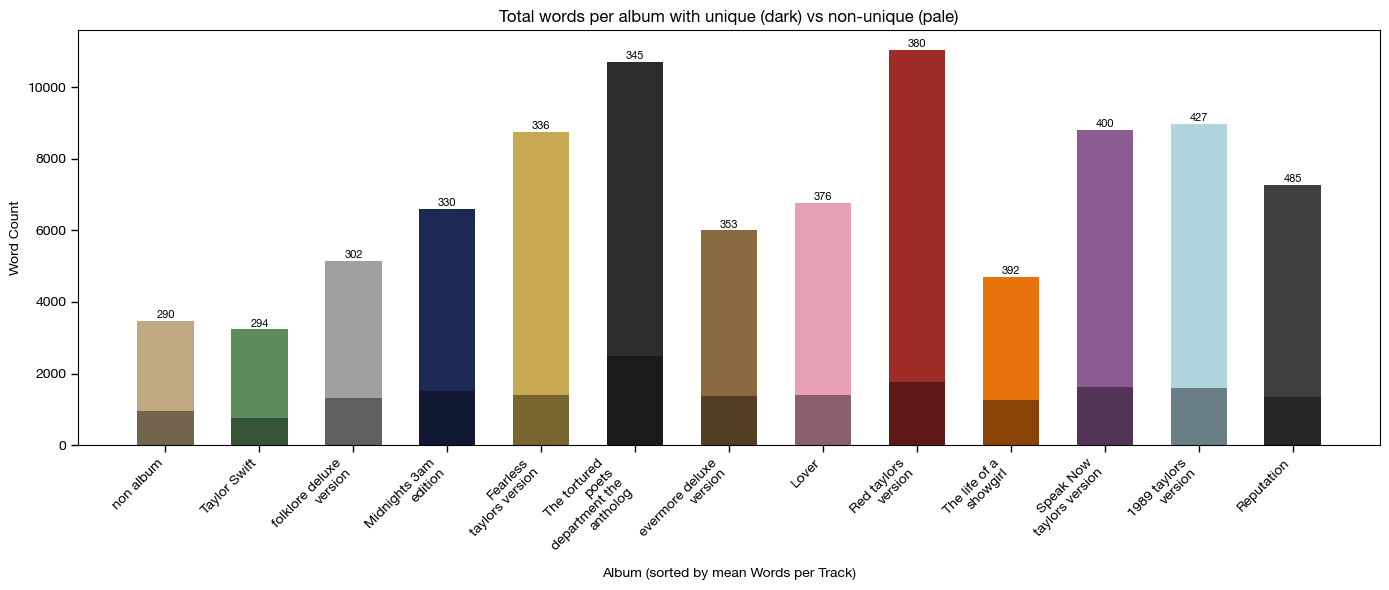

In [124]:
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

plt.rcParams["font.family"] = "Helvetica Neue"

pivot_words["Non_Unique_Words"] = pivot_words["Total_Words"] - pivot_words["Unique_Words"]
pivot_words_sorted = pivot_words.sort_values("Words_Per_Track")

def darken_color(hex_color, factor=0.6):
    hex_color = hex_color.lstrip("#")
    r, g, b = [int(hex_color[i:i+2], 16) for i in (0, 2, 4)]
    r, g, b = [int(c * factor) for c in (r, g, b)]
    return f"#{r:02x}{g:02x}{b:02x}"

#Set the colors for each album
album_colors = {
    "Taylor Swift":                          "#5B8C5A",
    pivot_words["Album"].unique()[6]:        "#8B5B92", #Speak now
    pivot_words["Album"].unique()[4]:        "#9E2B25", #Red
    pivot_words["Album"].unique()[5]:        "#404040", #Reputation
    "Lover":                                 "#E8A0B4",
    pivot_words["Album"].unique()[11]:       "#A0A0A0", #Folklore
    pivot_words["Album"].unique()[10]:       "#8C6A3F", #Evermore
    pivot_words["Album"].unique()[1]:        "#C8A951", #Fearless
    pivot_words["Album"].unique()[3]:        "#1B2954", #Midnights
    pivot_words["Album"].unique()[0]:        "#B0D5DF", #1989
    pivot_words["Album"].unique()[9]:         "#2C2C2C", #TTPD
    pivot_words["Album"].unique()[8]:         "#E8720C", #TLOAS
    pivot_words["Album"].unique()[12]:        "#C0A882",  # Non-album (warm parchment)
}

palette       = [album_colors.get(album, "#888888") for album in pivot_words_sorted["Album"]]
palette_dark  = [darken_color(c) for c in palette]


fig, ax = plt.subplots(figsize=(14, 6))

x = range(len(pivot_words_sorted))

ax.bar(x, pivot_words_sorted["Total_Words"], color=palette, width=0.6)
ax.bar(x, pivot_words_sorted["Unique_Words"], color=palette_dark, width=0.6)

for i, row in enumerate(pivot_words_sorted.itertuples()):
    ax.text(i, row.Total_Words + 20, f"{row.Words_Per_Track:.0f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(x)
ax.set_xlabel("Album (sorted by mean Words per Track)")
ax.set_ylabel("Word Count")
ax.set_title("Total words per album with unique (dark) vs non-unique (pale)")
ax.tick_params(axis='both', which='both', length=5, width=1)

## Split the line for long song name, e.g., All too well (10)
def wrap_label(label, max_width=15):
    words = label.split()
    lines, current = [], ""
    for word in words:
        if len(current) + len(word) + 1 <= max_width:
            current = (current + " " + word).strip()
        else:
            lines.append(current)
            current = word
    lines.append(current)
    return "\n".join(lines)

wrapped_labels = [wrap_label(name) for name in pivot_words_sorted["Album"]]
ax.set_xticklabels(wrapped_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("images/Total_words_per_album.png", dpi=300, bbox_inches='tight') 
plt.show()

The x-axis here is the mean of the total words per track. Reputation has the mean of 485 word counts per track.

#### Let's analyse her album over time

In [127]:
pivot_words_year = pivot_words.sort_values("Year").head(12)

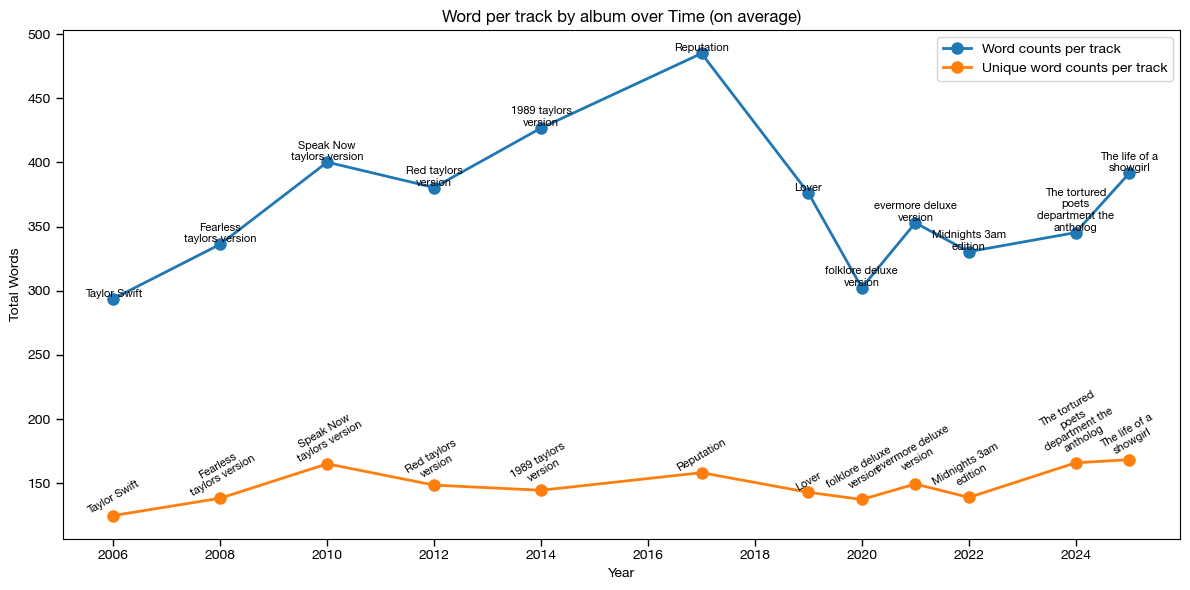

In [128]:
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(pivot_words_year["Year"],pivot_words_year["Words_Per_Track"], 
        marker="o", linewidth=2, markersize=8, label = "Word counts per track")

ax.plot(pivot_words_year["Year"],pivot_words_year["Unique_Words_Per_Track"], 
        marker="o", linewidth=2, markersize=8, label = "Unique word counts per track")

for _, row in pivot_words_year.iterrows():
    ax.text(row["Year"], row["Words_Per_Track"] + 0.002, 
            wrap_label(row["Album"]), ha="center", va="bottom", fontsize=8, rotation=0)
    ax.text(row["Year"], row["Unique_Words_Per_Track"] + 0.002, 
            wrap_label(row["Album"]), ha="center", va="bottom", fontsize=8, rotation=30)

ax.set_xlabel("Year")
ax.set_ylabel("Total Words")
ax.set_title("Word per track by album over Time (on average)")
ax.tick_params(axis='both', which='both', length=5, width=1)
ax.legend()

plt.tight_layout()
plt.savefig("images/Word_per_track_over_time.png", dpi=300, bbox_inches='tight') 
plt.show()

#### What is her unique word ratio over time?

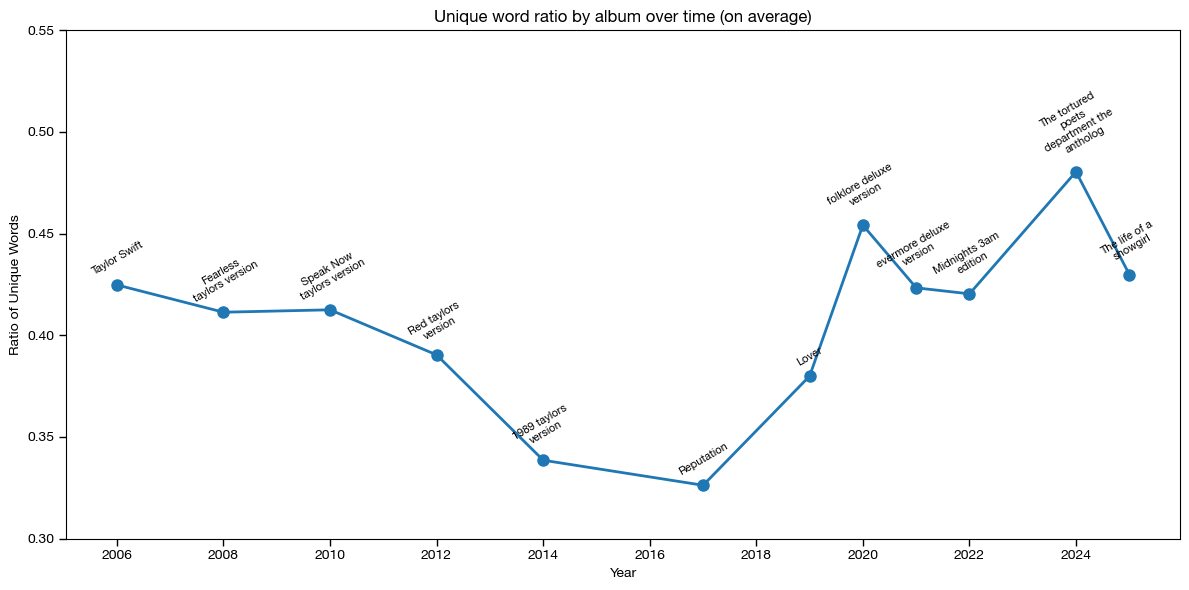

In [130]:
pivot_words_year=pivot_words.sort_values("Year").head(12)
fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(pivot_words_year["Year"],pivot_words_year["Ratio_unique"], 
        marker="o", linewidth=2, markersize=8)

for _, row in pivot_words_year.iterrows():
    ax.text(row["Year"], row["Ratio_unique"] + 0.004, 
            wrap_label(row["Album"]), ha="center", va="bottom", fontsize=8, rotation=30)

ax.set_xlabel("Year")
ax.set_ylabel("Ratio of Unique Words")
ax.set_title("Unique word ratio by album over time (on average)")
ax.tick_params(axis='both', which='both', length=5, width=1)
ax.set_ylim(0.3,0.55)

plt.tight_layout()
plt.savefig("images/Unique_word_per_track_over_time.png", dpi=300, bbox_inches='tight') 
plt.show()

## Analysing words by song

### Creating clean word dataframe

In [133]:
#Create a clean word dataframe
import string

word_records = []
for _, row in ts_lyrics.iterrows():
    for word in row["Lyrics"].split():
        clean_word = re.sub(r"['\u2019\u2018`].*", "", word.strip(string.punctuation)) # remove apostrophe and everything after
        
        if "-" in clean_word: #breaking the word with hyphen into individual word
            sub_words = clean_word.split("-")
            for sub_word in sub_words:
                sub_word = sub_word.strip(string.punctuation)
                if sub_word:
                    word_records.append((sub_word, len(sub_word), row["Album"], row["Song Name"]))
        else:
            if clean_word:
                word_records.append((clean_word, len(clean_word), row["Album"], row["Song Name"]))

words_df_clean = pd.DataFrame(word_records, columns=["Word", "Length", "Album", "Song Name"])

In [134]:
words_df_clean.info()

word_total = len(words_df_clean["Word"])
word_unique = len(words_df_clean["Word"].unique())

print("Total songs found are", len(ts_lyrics["Song Name"]))
print("Total words found are", word_total)
print("Unique words found are", word_unique)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 92191 entries, 0 to 92190
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   Word       92191 non-null  object
 1   Length     92191 non-null  int64 
 2   Album      92191 non-null  object
 3   Song Name  92191 non-null  object
dtypes: int64(1), object(3)
memory usage: 2.8+ MB
Total songs found are 251
Total words found are 92191
Unique words found are 6014


### Words by songs

In [136]:
word_by_songs = words_df_clean.groupby("Song Name").agg(
    Word_count=("Word", "count"),
    Word_unique=("Word", "nunique")
).reset_index()
word_by_songs["ratio_unique_total"] = word_by_songs["Word_unique"] / word_by_songs["Word_count"]
word_by_songs.describe()

,Word_count,Word_unique,ratio_unique_total
count,251.000000,251.000000,251.000000
mean,367.294821,136.258964,0.384310
std,99.075046,31.370315,0.083674
min,156.000000,76.000000,0.158192
25%,304.000000,115.000000,0.330208
50%,360.000000,135.000000,0.383333
75%,418.500000,152.000000,0.432875
max,978.000000,349.000000,0.633333


Can you guess what track has the highest word with 978 word counts? A hint is it's a 10-min song.
What stands out to me is that, on average, there is 38% of unique words in a song. I am very curious now which track has the highest unqiue ration with 63%

#### Word distribution

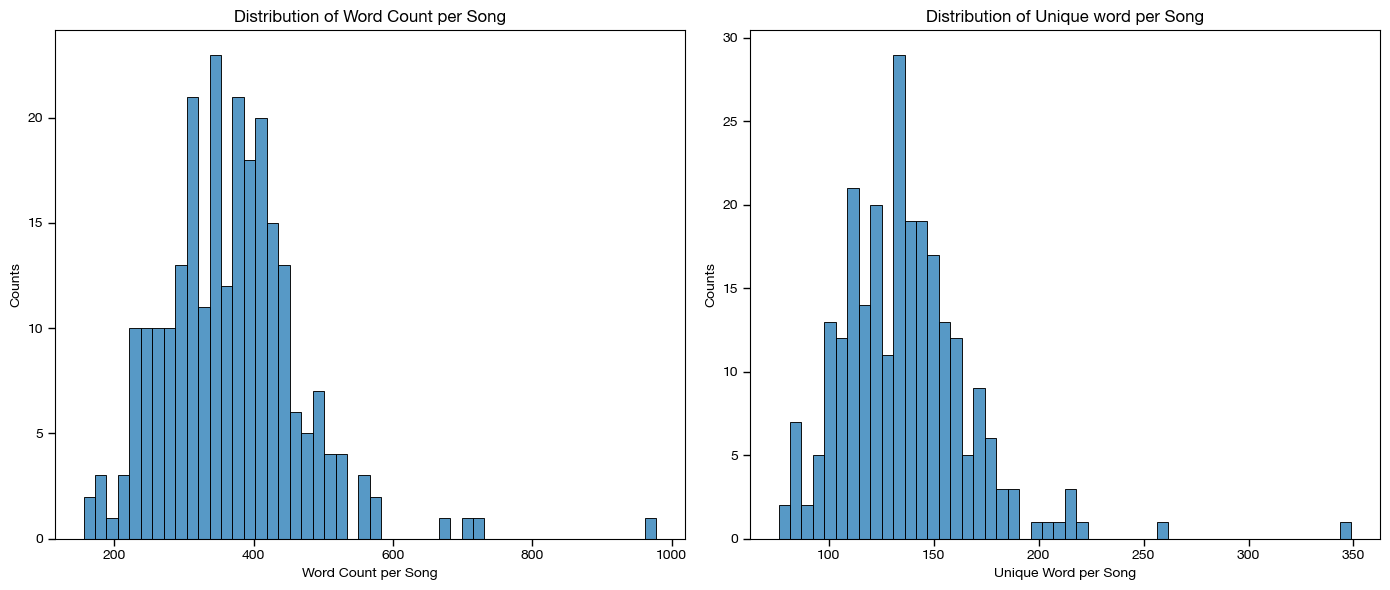

In [139]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.histplot(data=word_by_songs, x="Word_count", bins=50, ax=axes[0])
axes[0].set_xlabel("Word Count per Song")
axes[0].set_ylabel("Counts")
axes[0].set_title("Distribution of Word Count per Song")
axes[0].tick_params(axis='both', which='both', length=5, width=1)

sns.histplot(data=word_by_songs, x="Word_unique", bins=50, ax=axes[1])
axes[1].set_ylabel("Counts")
axes[1].set_xlabel("Unique Word per Song")
axes[1].set_title("Distribution of Unique word per Song")
axes[1].tick_params(axis='both', which='both', length=5, width=1)

plt.tight_layout()
plt.savefig("images/word_histograms.png", dpi=300, bbox_inches='tight') 
plt.show()

#### Top songs by word count

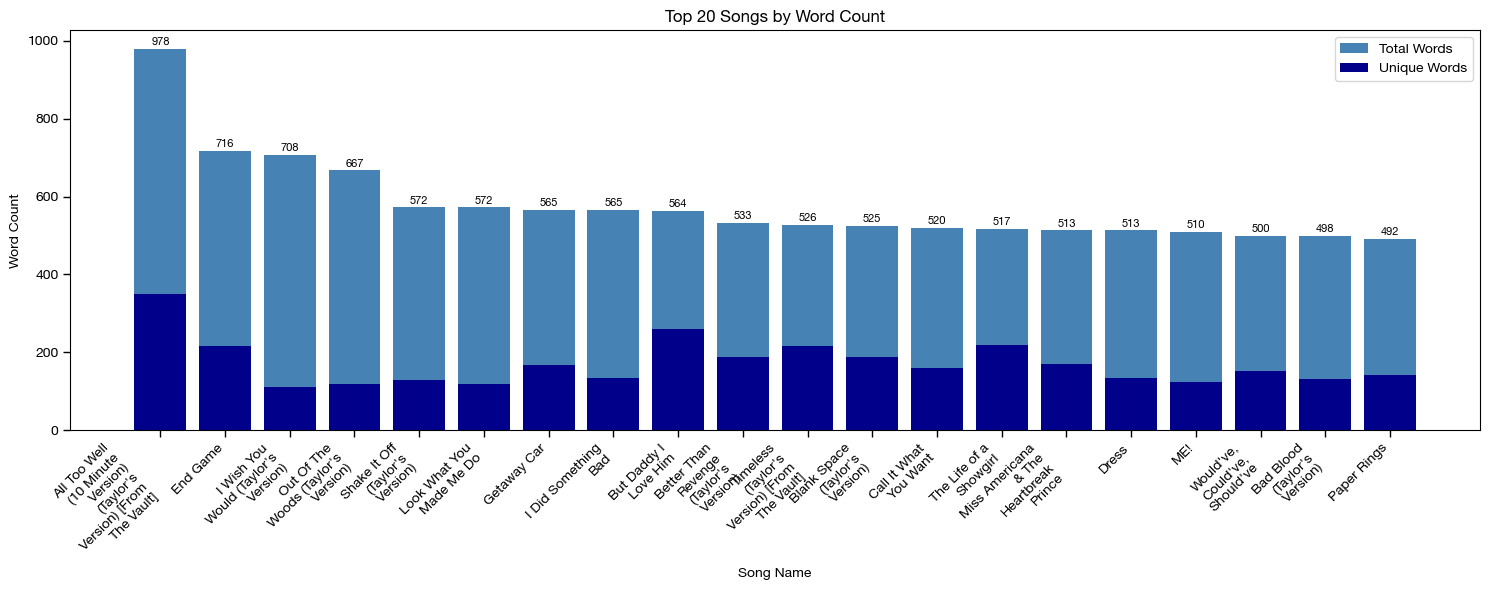

In [141]:
## Get top songs by word counts
top_songs= word_by_songs.sort_values(["Word_count", "Word_unique"], ascending=False).head(20)

## Create a bar chart
fig, ax = plt.subplots(figsize=(15, 6))

ax.bar(range(len(top_songs)), top_songs["Word_count"], 
       color="steelblue", label="Total Words")
ax.bar(range(len(top_songs)), top_songs["Word_unique"], 
       color="darkblue", label="Unique Words")
 
for i, row in enumerate(top_songs.itertuples()):
    ax.text(i, row.Word_count + 5, str(row.Word_count),
            ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(range(len(top_songs)))
ax.set_xlabel("Song Name")
ax.set_ylabel("Word Count")
ax.set_title("Top 20 Songs by Word Count")
ax.legend()
ax.tick_params(axis='both', which='both', length=5, width=1)

wrapped_labels = [wrap_label(name) for name in top_songs["Song Name"]]
ax.set_xticklabels(wrapped_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("images/top_songs_by_words.png", dpi=300, bbox_inches='tight') 
plt.show()

Clearly, All too well 10-min version should be there.

#### Smallest songs by count

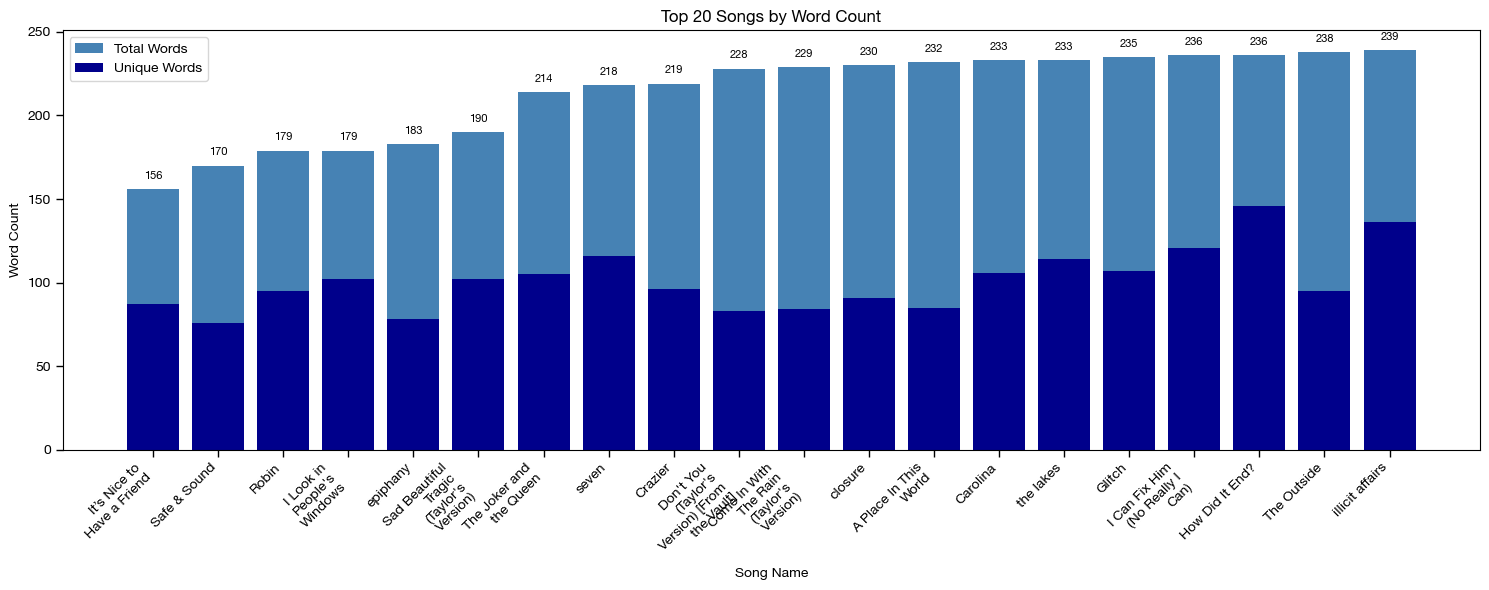

In [144]:
## Get top songs by word counts
top_songs= word_by_songs.sort_values(["Word_count", "Word_unique"], ascending=True).head(20)

## Create a bar chart
fig, ax = plt.subplots(figsize=(15, 6))

ax.bar(range(len(top_songs)), top_songs["Word_count"], 
       color="steelblue", label="Total Words")
ax.bar(range(len(top_songs)), top_songs["Word_unique"], 
       color="darkblue", label="Unique Words")
 
for i, row in enumerate(top_songs.itertuples()):
    ax.text(i, row.Word_count + 5, str(row.Word_count),
            ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(range(len(top_songs)))
ax.set_xlabel("Song Name")
ax.set_ylabel("Word Count")
ax.set_title("Top 20 Songs by Word Count")
ax.legend()
ax.tick_params(axis='both', which='both', length=5, width=1)

wrapped_labels = [wrap_label(name) for name in top_songs["Song Name"]]
ax.set_xticklabels(wrapped_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("images/smallest_songs_by_words.png", dpi=300, bbox_inches='tight') 
plt.show()

One shouldn't be surprised that it's nice to have a firend is only with a length of 2:30 mins.

#### Top song by unique words

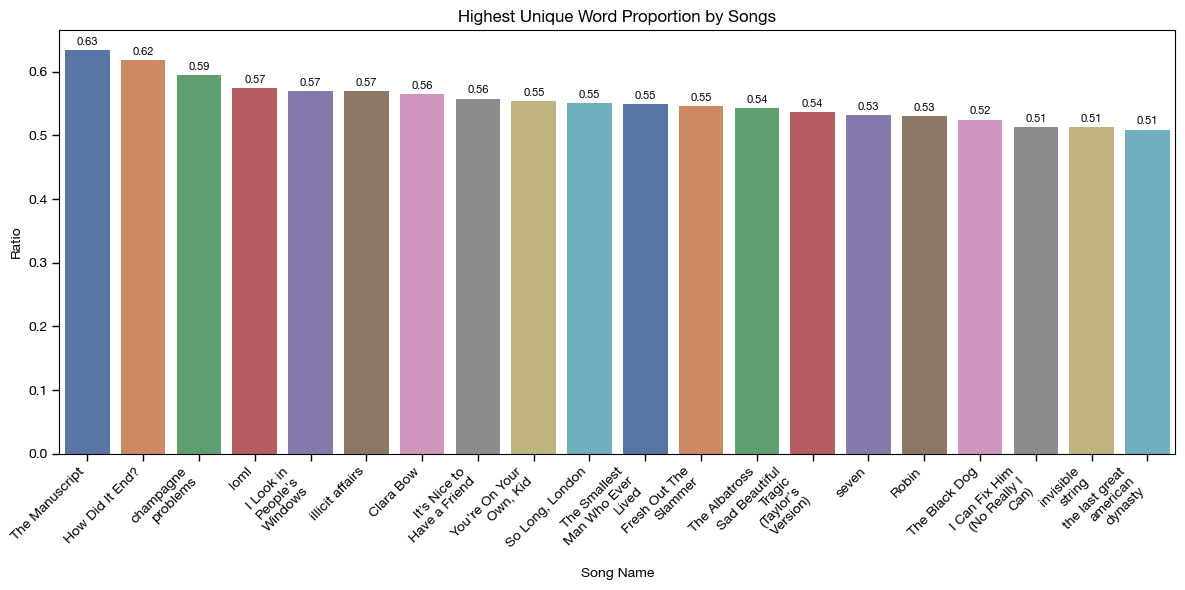

In [147]:
## Get top songs by ratio of unique songs
top_unique_songs = word_by_songs.sort_values("ratio_unique_total", ascending=False).head(20)

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=top_unique_songs, x="Song Name", y="ratio_unique_total", 
            hue="Song Name", palette="deep", legend=False, ax=ax)

for i, row in enumerate(top_unique_songs.itertuples()):
    ax.text(i, row.ratio_unique_total + 0.005, f"{row.ratio_unique_total:.2f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(range(len(top_unique_songs)))
ax.set_ylabel("Ratio")
ax.set_title("Highest Unique Word Proportion by Songs")
ax.tick_params(axis='both', which='both', length=5, width=1)
wrapped_labels = [wrap_label(name) for name in top_unique_songs["Song Name"]]
ax.set_xticklabels(wrapped_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("images/top_unique_songs_by_ratio.png", dpi=300, bbox_inches='tight') 
plt.show()

This is very interesting reults, especially, there are 12 songs from TTPD anthology. Also notice that "It's nice to have a friend" is the smallest song.

#### Least unique propotion songs

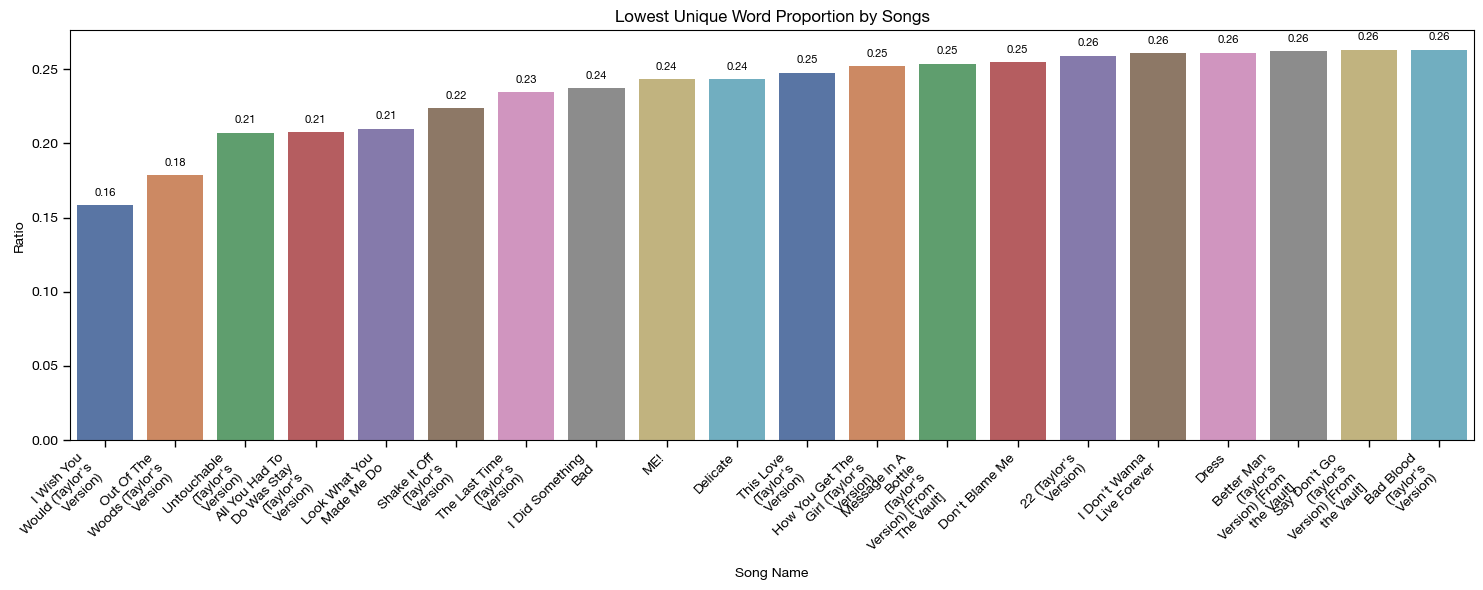

In [150]:
## Get top songs by ratio of unique songs
top_unique_songs = word_by_songs.sort_values("ratio_unique_total", ascending=True).head(20)

fig, ax = plt.subplots(figsize=(15, 6))
sns.barplot(data=top_unique_songs, x="Song Name", y="ratio_unique_total", 
            hue="Song Name", palette="deep", legend=False, ax=ax)

for i, row in enumerate(top_unique_songs.itertuples()):
    ax.text(i, row.ratio_unique_total + 0.005, f"{row.ratio_unique_total:.2f}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xticks(range(len(top_unique_songs)))
ax.set_ylabel("Ratio")
ax.set_title("Lowest Unique Word Proportion by Songs")
ax.tick_params(axis='both', which='both', length=5, width=1)
wrapped_labels = [wrap_label(name) for name in top_unique_songs["Song Name"]]
ax.set_xticklabels(wrapped_labels, rotation=45, ha="right")

plt.tight_layout()
plt.savefig("images/least_unique_songs_by_ratio.png", dpi=300, bbox_inches='tight') 
plt.show()

I am not surprised at all. I wish you would and out of the woods are the song that repeat these title words multiple times in the songs. There are 8 songs from 1989!

### Analysing all words

#### Finding the longes word

In [154]:
#Finding the logest words
words_df_clean.drop_duplicates(subset=["Word", "Song Name"]).sort_values("Length", ascending=False).head(20).set_index("Length")

,Word,Album,Song Name
Length,,,
17,Miscommunications,Midnights 3am edition,Question..
17,Miscommunications,Speak Now taylors version,The Story Of Us (Taylor's Version)
15,Disappointments,evermore deluxe version,coney island
15,Sanctimoniously,The tortured poets department the antholog,But Daddy I Love Him
14,responsibility,Red taylors version,Girl At Home (Taylor's Version)
14,insurmountable,folklore deluxe version,the lakes
14,constellations,Midnights 3am edition,High Infidelity
14,underestimated,Speak Now taylors version,Better Than Revenge (Taylor's Version)
14,sophistication,Speak Now taylors version,Better Than Revenge (Taylor's Version)


#### The most frequently used words with length >= 7

It is more meaning to look for terms with long lenght.Otherwise, we might encounter terms like pronouns, which are the most used in any songs.

Here, let's define a long word as a word that have a length >= 7. 

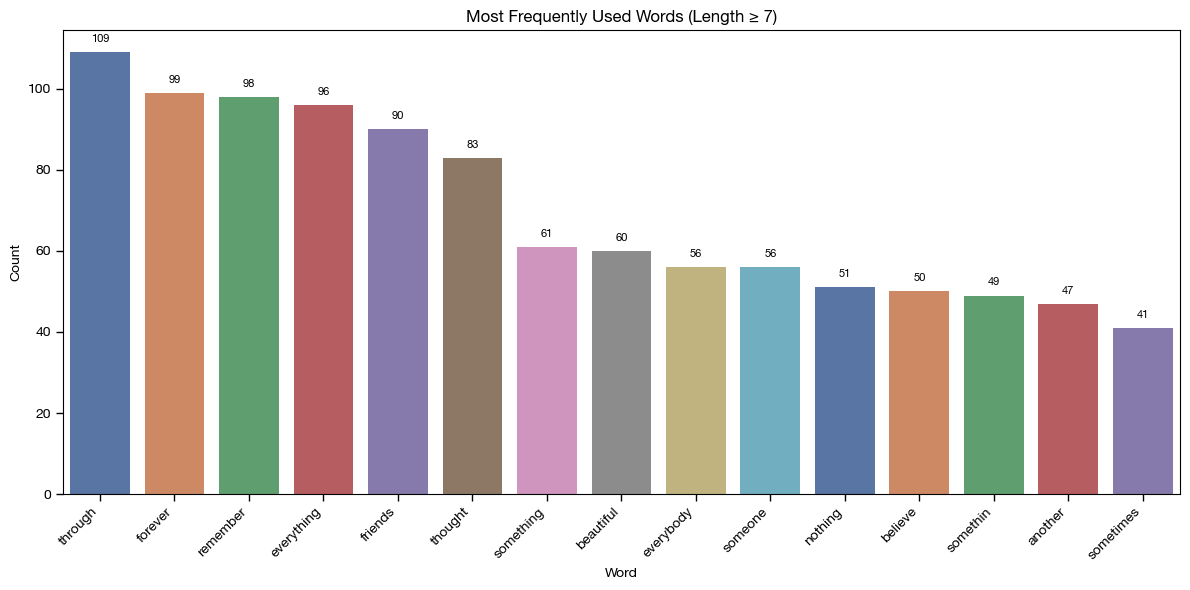

In [157]:
filtered_long = words_df_clean[words_df_clean["Length"] >= 7]
top_words = filtered_long["Word"].str.lower().value_counts().head(15).reset_index()
top_words.columns = ["Word", "Count"]

fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(data=top_words, x="Word", y="Count", hue="Word", palette="deep", legend=False, ax=ax)
for i, row in enumerate(top_words.itertuples()):
    ax.text(i, row.Count + 2, f"{row.Count}",
            ha="center", va="bottom", fontsize=8, fontweight="bold")

ax.set_xlabel("Word")
ax.set_ylabel("Count")
ax.set_title("Most Frequently Used Words (Length ≥ 7)")
ax.tick_params(axis='both', which='both', length=5, width=1)
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.savefig("images/most_used_words.png", dpi=300, bbox_inches='tight') 
plt.show()

Obviously, her favourite noun word (that is longer than 6 letters) is "forever". Let's trace back this word which track it appears and how many times.

#### Where to find "forever"?

In [160]:
(words_df_clean[words_df_clean["Word"].str.lower() == "forever"]
 .groupby(["Song Name", "Album"])
 .size()
 .reset_index(name="Count")
 .sort_values("Count", ascending=False)
 .set_index("Count"))

,Song Name,Album
Count,,
10,Elizabeth Taylor,The life of a showgirl
8,Forever & Always (Taylor's Version),Fearless taylors version
8,Forever Winter (Taylor’s Version) [From the Va...,Red taylors version
7,How You Get The Girl (Taylor's Version),1989 taylors version
5,Lover,Lover
5,Enchanted (Taylor's Version),Speak Now taylors version
5,Wonderland (Taylor's Version),1989 taylors version
5,Say Don’t Go (Taylor’s Version) [From the Vault],1989 taylors version
5,Last Kiss (Taylor's Version),Speak Now taylors version


#### What is the "long" word that is used the most in a single song?

In [162]:
### Long words that are used the most in a song
(filtered_long
 .groupby([ "Word", "Song Name", "Album"])
 .size()
 .reset_index(name="Count")
 .sort_values("Count", ascending=False)
 .head(25)
 .set_index("Count"))

,Word,Song Name,Album
Count,,,
38,daylight,Daylight,Lover
24,trouble,I Knew You Were Trouble (Taylor's Version),Red taylors version
22,getaway,Getaway Car,Reputation
22,starlight,Starlight (Taylor's Version),Red taylors version
21,Wonderland,Wonderland (Taylor's Version),1989 taylors version
20,everybody,Girl At Home (Taylor's Version),Red taylors version
19,Welcome,Welcome To New York (Taylor's Version),1989 taylors version
18,Florida,Florida!!!,The tortured poets department the antholog
18,remember,All Too Well (10 Minute Version) (Taylor's Ver...,Red taylors version


In [163]:
from collections import Counter

bigrams = []
for _, row in ts_lyrics.iterrows():
    words = row["Lyrics"].split()
    words = [re.sub(r"['\u2019\u2018`].*", "", w.strip(string.punctuation)).lower() for w in words]
    words = [w for w in words if w]
    for i in range(len(words) - 1):
        bigrams.append((words[i], words[i+1]))

bigram_counts = Counter(bigrams)
bigram_df = pd.DataFrame(bigram_counts.most_common(10), columns=["Bigram", "Count"])
bigram_df

,Bigram,Count
0,"(and, i)",526
1,"(in, the)",416
2,"(but, i)",254
3,"(i, was)",242
4,"(i, can)",236
5,"(i, don)",205
6,"(on, the)",196
7,"(and, you)",195
8,"(i, know)",182
9,"(you, were)",175
